In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [3]:
# (1) 读取数据并编码分类变量
data = pd.read_csv('A.csv')  # 替换为你的数据文件路径
data.tail()

,id,年龄,收入,爱好,信用,购买
9,10,老,中,是,中,是
10,11,青,中,是,优,是
11,12,中,中,否,优,是
12,13,中,高,是,中,是
13,14,老,中,否,优,否


In [4]:
data=data.drop('id',axis=1)

In [5]:
data

,年龄,收入,爱好,信用,购买
0,青,高,否,中,否
1,青,高,否,优,否
2,中,高,否,中,是
3,老,中,否,中,是
4,老,低,是,中,是
5,老,低,是,优,否
6,中,低,是,优,是
7,青,中,否,中,否
8,青,低,是,中,是
9,老,中,是,中,是


# 一定要注意是否含有缺失值NaN，如果含有缺失值，用data.dropna(inplace=True)将其删除

In [6]:
# 对所有文本型的分类变量进行编码
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

# 假设最后一列是目标变量Y，其余是特征X
X = data.iloc[:, :-1]
Y = data.iloc[:, -1]

In [7]:
# (2) 使用决策树分类器生成模型
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X, Y)

DecisionTreeClassifier(random_state=42)

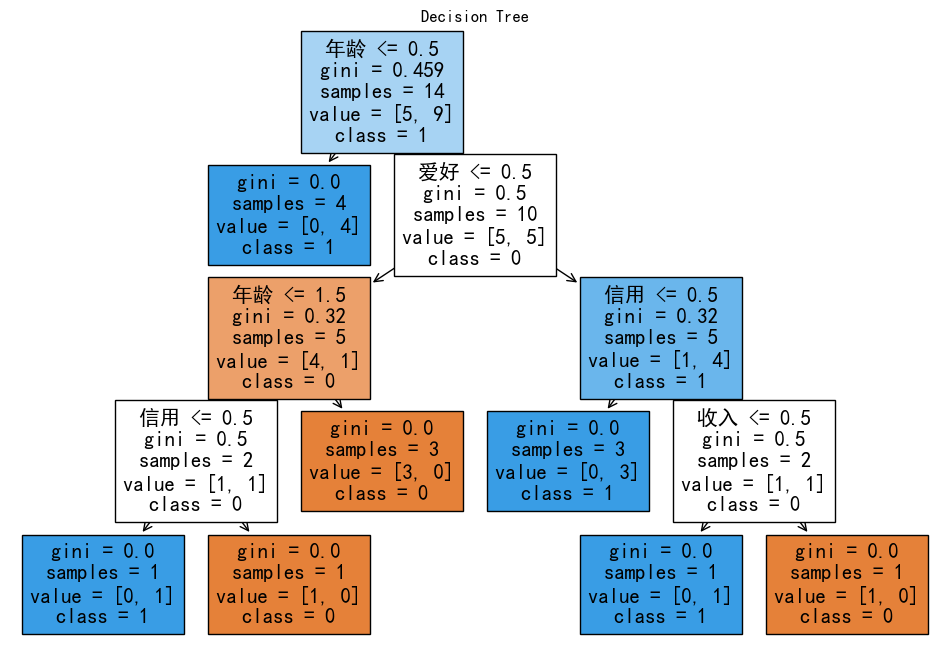

In [10]:
# (3) 绘制决策树
plt.figure(figsize=(12, 8))
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plot_tree(clf, feature_names=X.columns, class_names=[str(cls) for cls in set(Y)], filled=True)
plt.title("Decision Tree")
plt.show()